In [1]:
import scipy as sp
import numpy as np
import pandas as pd
import pickle
import os
import ast
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# pd.set_option('display.max_rows', 50)

In [2]:
def mean_confidence_interval(x, confidence=0.95):
    m, se = np.mean(x), sp.stats.sem(x)
    h = se * sp.stats.t.ppf((1 + confidence) / 2., x.shape[0] - 1)
    return np.round(m - h, 2), np.round(m, 2), np.round(m + h, 2)

In [3]:
folder_path = "./new_table_results/"
files = [folder_path + entry.name for entry in os.scandir(folder_path) if entry.is_file()]
# print(files)

In [21]:
final = pd.DataFrame()
for file in tqdm(files):
    with open(file, "rb") as f:
        results = pickle.load(f)

    keys = [x for x in results.keys() if "mask" not in x and "true" not in x]
    processed_results = {key: {e: [] for e in ["value", "time"]} for key in keys}
    
    for key in keys:
        tmp_mean = np.mean((results[key]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=0)
        processed_results[key]["value"] = sorted(list(tmp_mean))
        processed_results[key]["time"] = sorted(results[key]["time"])

    tmp = pd.DataFrame(processed_results).transpose()
    tmp.reset_index(inplace=True)
    
    tmp["sigma_min"] = tmp["index"].apply(lambda x: x.split()[0]).astype(float)
    tmp["sigma"] = tmp["index"].apply(lambda x: x.split()[1]).astype(float)
    tmp["score_type"] = tmp["index"].apply(lambda x: x.split()[2])
    
    tmp["value"] = tmp.value.apply(lambda x: np.round(x, 2))
    tmp["time"] = tmp.time.apply(lambda x: np.round(x, 2))
    
    special = file.split("/")[-1][:-4].split(".")[0].split("_")
    tmp["loc"] = int(special[-3])
    tmp["num_dims"] = int(special[-2])
    tmp["num_samples"] = int(special[-1])
    tmp["type"] = special[0]
    
    tmp.drop("index", inplace=True, axis=1)
    tmp = tmp[["type", "loc", "num_dims", "num_samples", "sigma", "sigma_min", "score_type", "value", "time"]]

    final = pd.concat([final, tmp])
final.sort_values(["type", "loc", "num_dims", "num_samples", "sigma", "sigma_min", "score_type"], ascending=True, inplace=True)

  0%|          | 0/120 [00:00<?, ?it/s]

In [22]:
final["mean_value"] = final.value.apply(np.mean)
final["var_value"] = final.value.apply(np.std)

In [23]:
final[(final.num_dims == 20) & (final.num_samples == 110_000) & (final.type == "val")].sort_values("mean_value")

,type,loc,num_dims,num_samples,sigma,sigma_min,score_type,value,time,mean_value,var_value
7,val,1,20,110000,0.00,0.0001,rl,"[0.31, 0.33, 0.46]","[18.41, 20.96, 22.03]",0.366667,0.066500
5,val,1,20,110000,0.00,0.0010,rl,"[0.3, 0.32, 0.59]","[19.17, 19.47, 21.01]",0.403333,0.132246
1,val,1,20,110000,0.10,0.0000,rl,"[0.31, 0.46, 0.49]","[21.67, 22.2, 23.85]",0.420000,0.078740
17,val,1,20,110000,0.25,0.0000,rl,"[0.38, 0.47, 0.59]","[18.99, 19.36, 20.38]",0.480000,0.086023
3,val,1,20,110000,0.00,0.0100,rl,"[0.56, 0.57, 0.59]","[19.74, 20.36, 24.29]",0.573333,0.012472
11,val,1,20,110000,1.00,0.0000,rl,"[0.5, 0.51, 0.89]","[13.46, 13.85, 16.47]",0.633333,0.181537
9,val,1,20,110000,0.00,0.0000,rl,"[0.23, 0.41, 1.27]","[18.34, 18.88, 19.42]",0.636667,0.453823
13,val,1,20,110000,0.75,0.0000,rl,"[0.35, 0.67, 1.15]","[14.14, 15.65, 18.32]",0.723333,0.328769
1,val,1,20,110000,0.00,0.1000,rl,"[0.68, 0.73, 0.83]","[19.22, 21.32, 21.71]",0.746667,0.062361
6,val,1,20,110000,0.00,0.0001,naive,"[0.82, 0.85, 0.97]","[40.32, 40.79, 44.82]",0.880000,0.064807


In [24]:
tmp = pd.read_csv("results_time_score_matching_sweep.csv")
tmp.columns = ["num_dims", "loc", "score_type", "lr", "sb_variance", "iter", "val_mse", "test_mse"]
tmp = tmp.groupby(["num_dims", "loc", "score_type", "lr", "sb_variance"])[["val_mse", "test_mse"]].mean().reset_index()
tmp = tmp[(tmp["loc"].isin([1, 2])) & (tmp.score_type.apply(lambda x: "-v" not in x))].copy()

In [25]:
tmp[(tmp["loc"] == 1) & (tmp.score_type == "CTSM_TwoSB")]

,num_dims,loc,score_type,lr,sb_variance,val_mse,test_mse
9,2,1,CTSM_TwoSB,0.0005,0.1,0.2714,0.2786
10,2,1,CTSM_TwoSB,0.0005,0.5,0.1172,0.1178
11,2,1,CTSM_TwoSB,0.0005,1.0,0.0508,0.0514
12,2,1,CTSM_TwoSB,0.0010,0.1,0.2806,0.2826
13,2,1,CTSM_TwoSB,0.0010,0.5,0.1114,0.1126
14,2,1,CTSM_TwoSB,0.0010,1.0,0.0420,0.0426
15,2,1,CTSM_TwoSB,0.0050,0.1,1.8734,1.8798
16,2,1,CTSM_TwoSB,0.0050,0.5,0.4796,0.4938
17,2,1,CTSM_TwoSB,0.0050,1.0,0.1946,0.1954
90,5,1,CTSM_TwoSB,0.0005,0.1,1.3022,1.3314


In [26]:
tmp = tmp[(tmp.lr == 0.0005) & (tmp.sb_variance == 1.0)].drop(["lr", "sb_variance", "val_mse"], axis=1).copy()
tmp["mean_value"] = tmp.test_mse
tmp["sigma"] = 0
tmp["sigma_min"] = 0

In [27]:
sc_df = final.copy()
final = final[(final.num_samples == 110_000) & (final.type == "test")].copy().drop(["type", "num_samples"], axis=1)

# tmp = pd.read_csv("concatenated_results.csv")
# tmp["value"] = tmp.value.apply(ast.literal_eval)
final = pd.concat([final, tmp])
final

,loc,num_dims,sigma,sigma_min,score_type,value,time,mean_value,var_value,test_mse
8,1,2,0.0,0.0000,naive,"[0.01, 0.03, 0.03]","[63.21, 67.74, 68.62]",0.023333,0.009428,NaN
9,1,2,0.0,0.0000,rl,"[0.01, 0.01, 0.02]","[20.43, 21.4, 22.76]",0.013333,0.004714,NaN
6,1,2,0.0,0.0001,naive,"[0.01, 0.02, 0.03]","[62.75, 63.08, 66.14]",0.020000,0.008165,NaN
7,1,2,0.0,0.0001,rl,"[0.01, 0.01, 0.01]","[20.34, 21.42, 23.05]",0.010000,0.000000,NaN
4,1,2,0.0,0.0010,naive,"[0.01, 0.02, 0.03]","[63.16, 65.33, 66.91]",0.020000,0.008165,NaN
...,...,...,...,...,...,...,...,...,...,...
290,2,20,0.0,0.0000,TSM_TwoSB,NaN,NaN,22.391600,NaN,22.3916
335,1,30,0.0,0.0000,CTSM_TwoSB,NaN,NaN,3.881400,NaN,3.8814
344,1,30,0.0,0.0000,TSM_TwoSB,NaN,NaN,4.992200,NaN,4.9922
362,2,30,0.0,0.0000,CTSM_TwoSB,NaN,NaN,48.484600,NaN,48.4846


In [28]:
tmp = pd.read_csv("gaussian_results.csv")[["num_dims", "loc", "value"]]
tmp.columns = ["num_dims", "loc", "mean_value"]
tmp["score_type"] = "classifier"
tmp["sigma"] = 0
tmp["sigma_min"] = 0
tmp

,num_dims,loc,mean_value,score_type,sigma,sigma_min
0,2,1.0,0.000173,classifier,0,0
1,5,1.0,0.001535,classifier,0,0
2,10,1.0,0.009180,classifier,0,0
3,20,1.0,0.071503,classifier,0,0
4,30,1.0,1.009372,classifier,0,0
5,2,2.0,0.000278,classifier,0,0
6,5,2.0,0.012290,classifier,0,0
7,10,2.0,16.580688,classifier,0,0
8,20,2.0,145.286225,classifier,0,0
9,30,2.0,544.635217,classifier,0,0


In [29]:
final = pd.concat([final, tmp])
final

,loc,num_dims,sigma,sigma_min,score_type,value,time,mean_value,var_value,test_mse
8,1.0,2,0.0,0.0000,naive,"[0.01, 0.03, 0.03]","[63.21, 67.74, 68.62]",0.023333,0.009428,NaN
9,1.0,2,0.0,0.0000,rl,"[0.01, 0.01, 0.02]","[20.43, 21.4, 22.76]",0.013333,0.004714,NaN
6,1.0,2,0.0,0.0001,naive,"[0.01, 0.02, 0.03]","[62.75, 63.08, 66.14]",0.020000,0.008165,NaN
7,1.0,2,0.0,0.0001,rl,"[0.01, 0.01, 0.01]","[20.34, 21.42, 23.05]",0.010000,0.000000,NaN
4,1.0,2,0.0,0.0010,naive,"[0.01, 0.02, 0.03]","[63.16, 65.33, 66.91]",0.020000,0.008165,NaN
...,...,...,...,...,...,...,...,...,...,...
5,2.0,2,0.0,0.0000,classifier,NaN,NaN,0.000278,NaN,NaN
6,2.0,5,0.0,0.0000,classifier,NaN,NaN,0.012290,NaN,NaN
7,2.0,10,0.0,0.0000,classifier,NaN,NaN,16.580688,NaN,NaN
8,2.0,20,0.0,0.0000,classifier,NaN,NaN,145.286225,NaN,NaN


In [31]:
final.drop(["test_mse", "var_value"], axis=1).to_csv("all_results.csv", index=None)

In [34]:
sigma = 0.1
df = final[(final.sigma_min.apply(lambda x: x in [1, 0, 1e-3])) & (final.sigma.apply(lambda x: x in [0, sigma])) & (final["loc"].isin([1, 2]))].copy()
df["scheduler_type"] = df.apply(lambda x: "noise on path" if x.sigma == sigma else ("noise at data" if x.sigma_min > 0 else (x.score_type if ("TSM" in x.score_type or "class" in x.score_type) else "deterministic path")), axis=1)

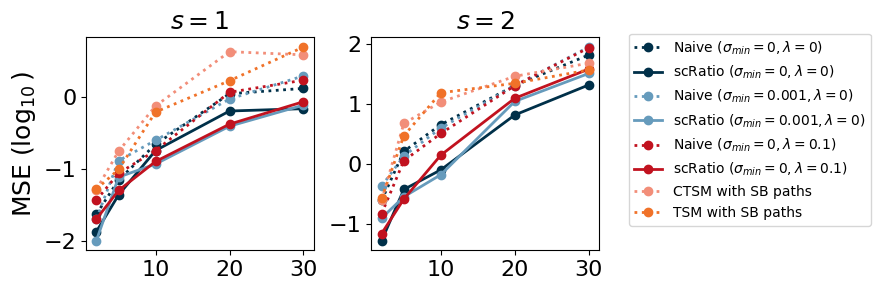

In [47]:
locs = df["loc"].unique()
fig, axes = plt.subplots(1, len(locs), figsize=(3*(len(locs) + 1), 3))

#780000
#C1121F
#FDF0D5
#003049
#669BBC
#F28E79
#001F36
#B7472F
#F07229

colors = {"noise on path": "#C1121F", "noise at data": "#669BBC", "deterministic path": "#003049", "CTSM_TwoSB": "#F28E79", "TSM_TwoSB": "#F07229", "classifier": "#FDF0D5"}
label_suffixes = {
    "noise on path": rf" $(\sigma_{{min}} = 0, \lambda = 0.1)$",
    "noise at data": rf" $(\sigma_{{min}} = 0.001, \lambda = 0)$",
    "deterministic path": rf" $(\sigma_{{min}} = 0, \lambda = 0)$",
    "CTSM_TwoSB": "CTSM with SB paths",
    "TSM_TwoSB": "TSM with SB paths",
    "classifier": "Classifier"
}

if len(locs) == 1:
    axes = [axes]

for idx, loc in enumerate(locs):
    if idx == 2:
        continue
    loc_data = df[df["loc"] == loc]
        
    for scheduler_type in loc_data.scheduler_type.unique():
        subset = loc_data[loc_data.scheduler_type == scheduler_type]
        subset = subset.sort_values('num_dims')

        if "class" in scheduler_type:
            continue
        elif "TSM" in scheduler_type:
            try:
                axes[idx].plot(
                    subset['num_dims'], 
                    np.log10(subset['mean_value']), 
                    marker='o',
                    label=label_suffixes[scheduler_type],
                    linestyle=":",
                    linewidth=2,
                    color=colors[scheduler_type]
                )
            except:
                continue
        else:
            axes[idx].plot(
                subset[subset.score_type == "naive"]['num_dims'], 
                np.log10(subset[subset.score_type == "naive"]['mean_value']), 
                marker='o',
                label="Naive" + label_suffixes[scheduler_type],
                linestyle=":",
                linewidth=2,
                color=colors[scheduler_type]
            )
    
            axes[idx].plot(
                subset[subset.score_type == "rl"]['num_dims'], 
                np.log10(subset[subset.score_type == "rl"]['mean_value']), 
                marker='o',
                label="scRatio" + label_suffixes[scheduler_type],
                linewidth=2,
                color=colors[scheduler_type]
            )

    # axes[idx].set_xlabel('Dimensionality', fontsize=18)
    if idx == 0:
        axes[idx].set_ylabel(r'MSE ($\log_{{10}}$)', fontsize=18)
    axes[idx].set_title(rf'$s = {int(loc)}$', fontsize=18)
    axes[idx].grid(visible=False)
    axes[idx].tick_params(labelsize=16)
    if idx == 1:
        axes[idx].legend(bbox_to_anchor=(1.1, 1.05))
        # axes[idx].legend(bbox_to_anchor=(1, 1), ncol=4)

plt.tight_layout()
plt.savefig("saved_plots/new_mse_plot.svg", dpi=300, bbox_inches="tight")
plt.show()

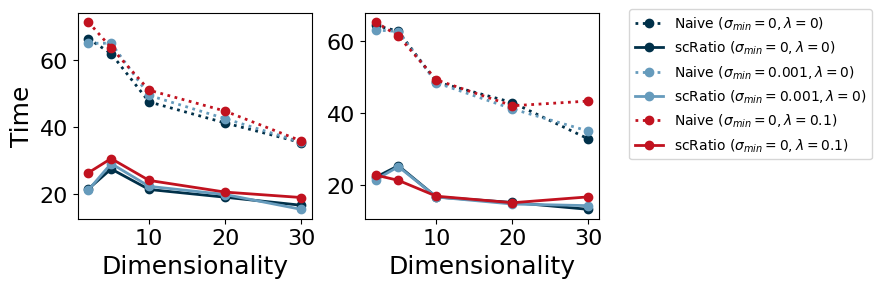

In [46]:
locs = df["loc"].unique()
fig, axes = plt.subplots(1, len(locs), figsize=(3*(len(locs) + 1), 3))

colors = {"noise on path": "#C1121F", "noise at data": "#669BBC", "deterministic path": "#003049"}
label_suffixes = {
    "noise on path": rf" $(\sigma_{{min}} = 0, \lambda = 0.1)$",
    "noise at data": rf" $(\sigma_{{min}} = 0.001, \lambda = 0)$",
    "deterministic path": rf" $(\sigma_{{min}} = 0, \lambda = 0)$"
}

if len(locs) == 1:
    axes = [axes]

for idx, loc in enumerate(locs):
    if idx == 2:
        continue
    loc_data = df[df["loc"] == loc]
        
    for scheduler_type in loc_data.scheduler_type.unique():
        if "TSM" in scheduler_type or "class" in scheduler_type:
            continue
        else:
            subset = loc_data[loc_data.scheduler_type == scheduler_type]
            subset = subset.sort_values('num_dims')
            
            axes[idx].plot(
                subset[subset.score_type == "naive"]['num_dims'], 
                subset[subset.score_type == "naive"]['time'].apply(np.mean), 
                marker='o',
                label="Naive" + label_suffixes[scheduler_type],
                linestyle=":",
                linewidth=2,
                color=colors[scheduler_type]
            )
    
            axes[idx].plot(
                subset[subset.score_type == "rl"]['num_dims'], 
                subset[subset.score_type == "rl"]['time'].apply(np.mean), 
                marker='o',
                label="scRatio" + label_suffixes[scheduler_type],
                linewidth=2,
                color=colors[scheduler_type]
            )

    axes[idx].set_xlabel('Dimensionality', fontsize=18)
    if idx == 0:
        axes[idx].set_ylabel('Time', fontsize=18)
    # axes[idx].set_title(rf'$s = {int(loc)}$', fontsize=18)
    axes[idx].grid(visible=False)
    axes[idx].tick_params(labelsize=16)
    if idx == 1:
        axes[idx].legend(bbox_to_anchor=(1.1, 1.05))

plt.tight_layout()
plt.savefig("saved_plots/new_time_plot.svg", dpi=300, bbox_inches="tight")
plt.show()

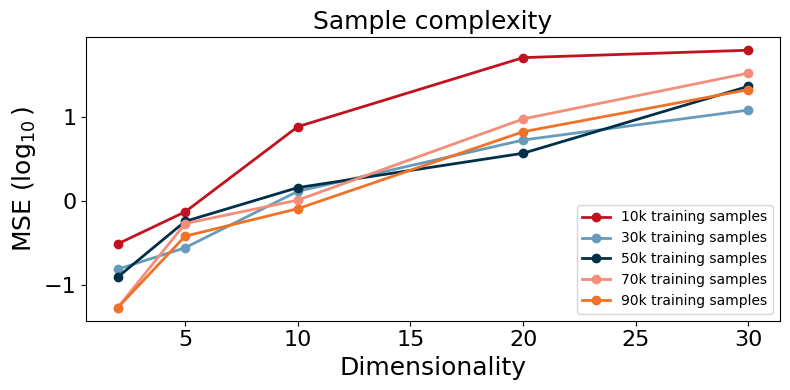

In [20]:
tmp = sc_df[(sc_df["loc"] == 2) & (sc_df.score_type == "rl") & (sc_df.type == "test") & (sc_df.sigma == 0) & (sc_df.sigma_min == 0)].copy()

fig = plt.figure(figsize=(8, 4))

colors = {30_000: "#C1121F", 50_000: "#669BBC", 70_000: "#003049", 90_000: "#F28E79", 110_000: "#F07229", 130_000: "#FDF0D5"}

num_samples = tmp.num_samples.unique()
for n in num_samples:
    plt.plot(
        tmp[tmp.num_samples == n]['num_dims'], 
        np.log10(tmp[tmp.num_samples == n]['mean_value']), 
        marker='o',
        label=f"{int((n - 20_000) / 1000)}k training samples",
        linewidth=2,
        color=colors[n]
    )

plt.xlabel('Dimensionality', fontsize=18)
plt.ylabel(r'MSE ($\log_{{10}}$)', fontsize=18)
plt.title("Sample complexity", fontsize=18)
plt.grid(visible=False)
plt.tick_params(labelsize=16)
plt.legend()

plt.tight_layout()
plt.savefig("saved_plots/sample_complexity.pdf", dpi=300, bbox_inches="tight")
plt.show()